# Configure Merge Module Params

This notebook should be used as a test for ensuring correct merge parameters before merge processing.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for merge processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [14]:
CONFIG_FILE_PATH = "config/config.yml"

In [15]:
import warnings
from pathlib import Path

import yaml
import pandas as pd

from lib.shared.file_utils import get_filename
from lib.shared.configuration_utils import (
    plot_combined_tile_grid,
    plot_merge_example,
    CONFIG_FILE_HEADER,
)
from lib.merge.hash import hash_cell_locations, initial_alignment
from lib.merge.eval_alignment import plot_alignment_quality

In [16]:
def find_closest_sites(ph_metadata, sbs_metadata, ph_tile_id):
    """
    Find closest SBS sites in sbs_metadata to a specific phenotype tile in ph_metadata.
    
    Args:
        ph_metadata: DataFrame with x_pos, y_pos columns
        sbs_metadata: DataFrame with x_pos, y_pos columns  
        ph_tile_id: ID of phenotype tile to find closest SBS sites for
    
    Returns:
        DataFrame of SBS sites sorted by distance to ph_tile_id
    """
    # Get phenotype tile coordinates
    ph_tile = ph_metadata[ph_metadata.tile == ph_tile_id]
    print(f"Finding closest SBS sites to phenotype tile ID: {ph_tile_id}")
    print(f"Phenotype tile coordinates: {ph_tile[['x_pos', 'y_pos']].iloc[0].to_dict()}")
    
    ph_x, ph_y = ph_tile['x_pos'].iloc[0], ph_tile['y_pos'].iloc[0]
    
    # Calculate distances to all SBS tiles
    distances = np.sqrt((sbs_metadata['x_pos'] - ph_x)**2 + (sbs_metadata['y_pos'] - ph_y)**2)
    
    # Return sorted results
    result = sbs_metadata.copy()
    result['distance'] = distances
    return result.sort_values('distance')

## <font color='red'>SET PARAMETERS</font>

### Determine merge plate-well combos
- `MERGE_COMBO_DF_FP`: Plate used for testing configuration

In [17]:
MERGE_COMBO_DF_FP = "config/merge_combo.tsv"

In [18]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

SBS_COMBO_FP = Path(config["preprocess"]["sbs_combo_fp"])
sbs_wildcard_combos = pd.read_csv(SBS_COMBO_FP, sep="\t")
PHENOTYPE_COMBO_FP = Path(config["preprocess"]["phenotype_combo_fp"])
phenotype_wildcard_combos = pd.read_csv(PHENOTYPE_COMBO_FP, sep="\t")

# Generate plate-well combinations for merge
sbs_combos = set(zip(sbs_wildcard_combos["plate"], sbs_wildcard_combos["well"]))
phenotype_combos = set(
    zip(phenotype_wildcard_combos["plate"], phenotype_wildcard_combos["well"])
)
# Check if SBS and PHENOTYPE have the same plate-well combinations
if sbs_combos == phenotype_combos:
    merge_wildcard_combos = pd.DataFrame(list(sbs_combos), columns=["plate", "well"])
else:
    warnings.warn(
        "SBS and PHENOTYPE do not have matching plate-well combinations. Merging requires identical sets."
    )
    merge_wildcard_combos = pd.DataFrame(columns=["plate", "well"])

merge_wildcard_combos.to_csv(MERGE_COMBO_DF_FP, sep="\t", index=False)
merge_wildcard_combos

,plate,well
0,1,A3
1,1,B2


## <font color='red'>SET PARAMETERS</font>

### Parameters for testing merge module
- `TEST_PLATE`: Plate used for testing configuration 
- `TEST_WELL`: Well identifier used for testing configuration 

### Parameters for metadata extraction
- `SBS_METADATA_CYCLE`: Cycle number for extracting SBS data positions
- `SBS_METADATA_CHANNEL`: Optional channel for SBS metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.
- `PH_METADATA_CHANNEL`: Optional channel for phenotype metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.

In [19]:
TEST_PLATE = 1
TEST_WELL = "A3"

SBS_METADATA_CYCLE = 1
SBS_METADATA_CHANNEL = None
PH_METADATA_CHANNEL = None

/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/shared/configuration_utils.py:302: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


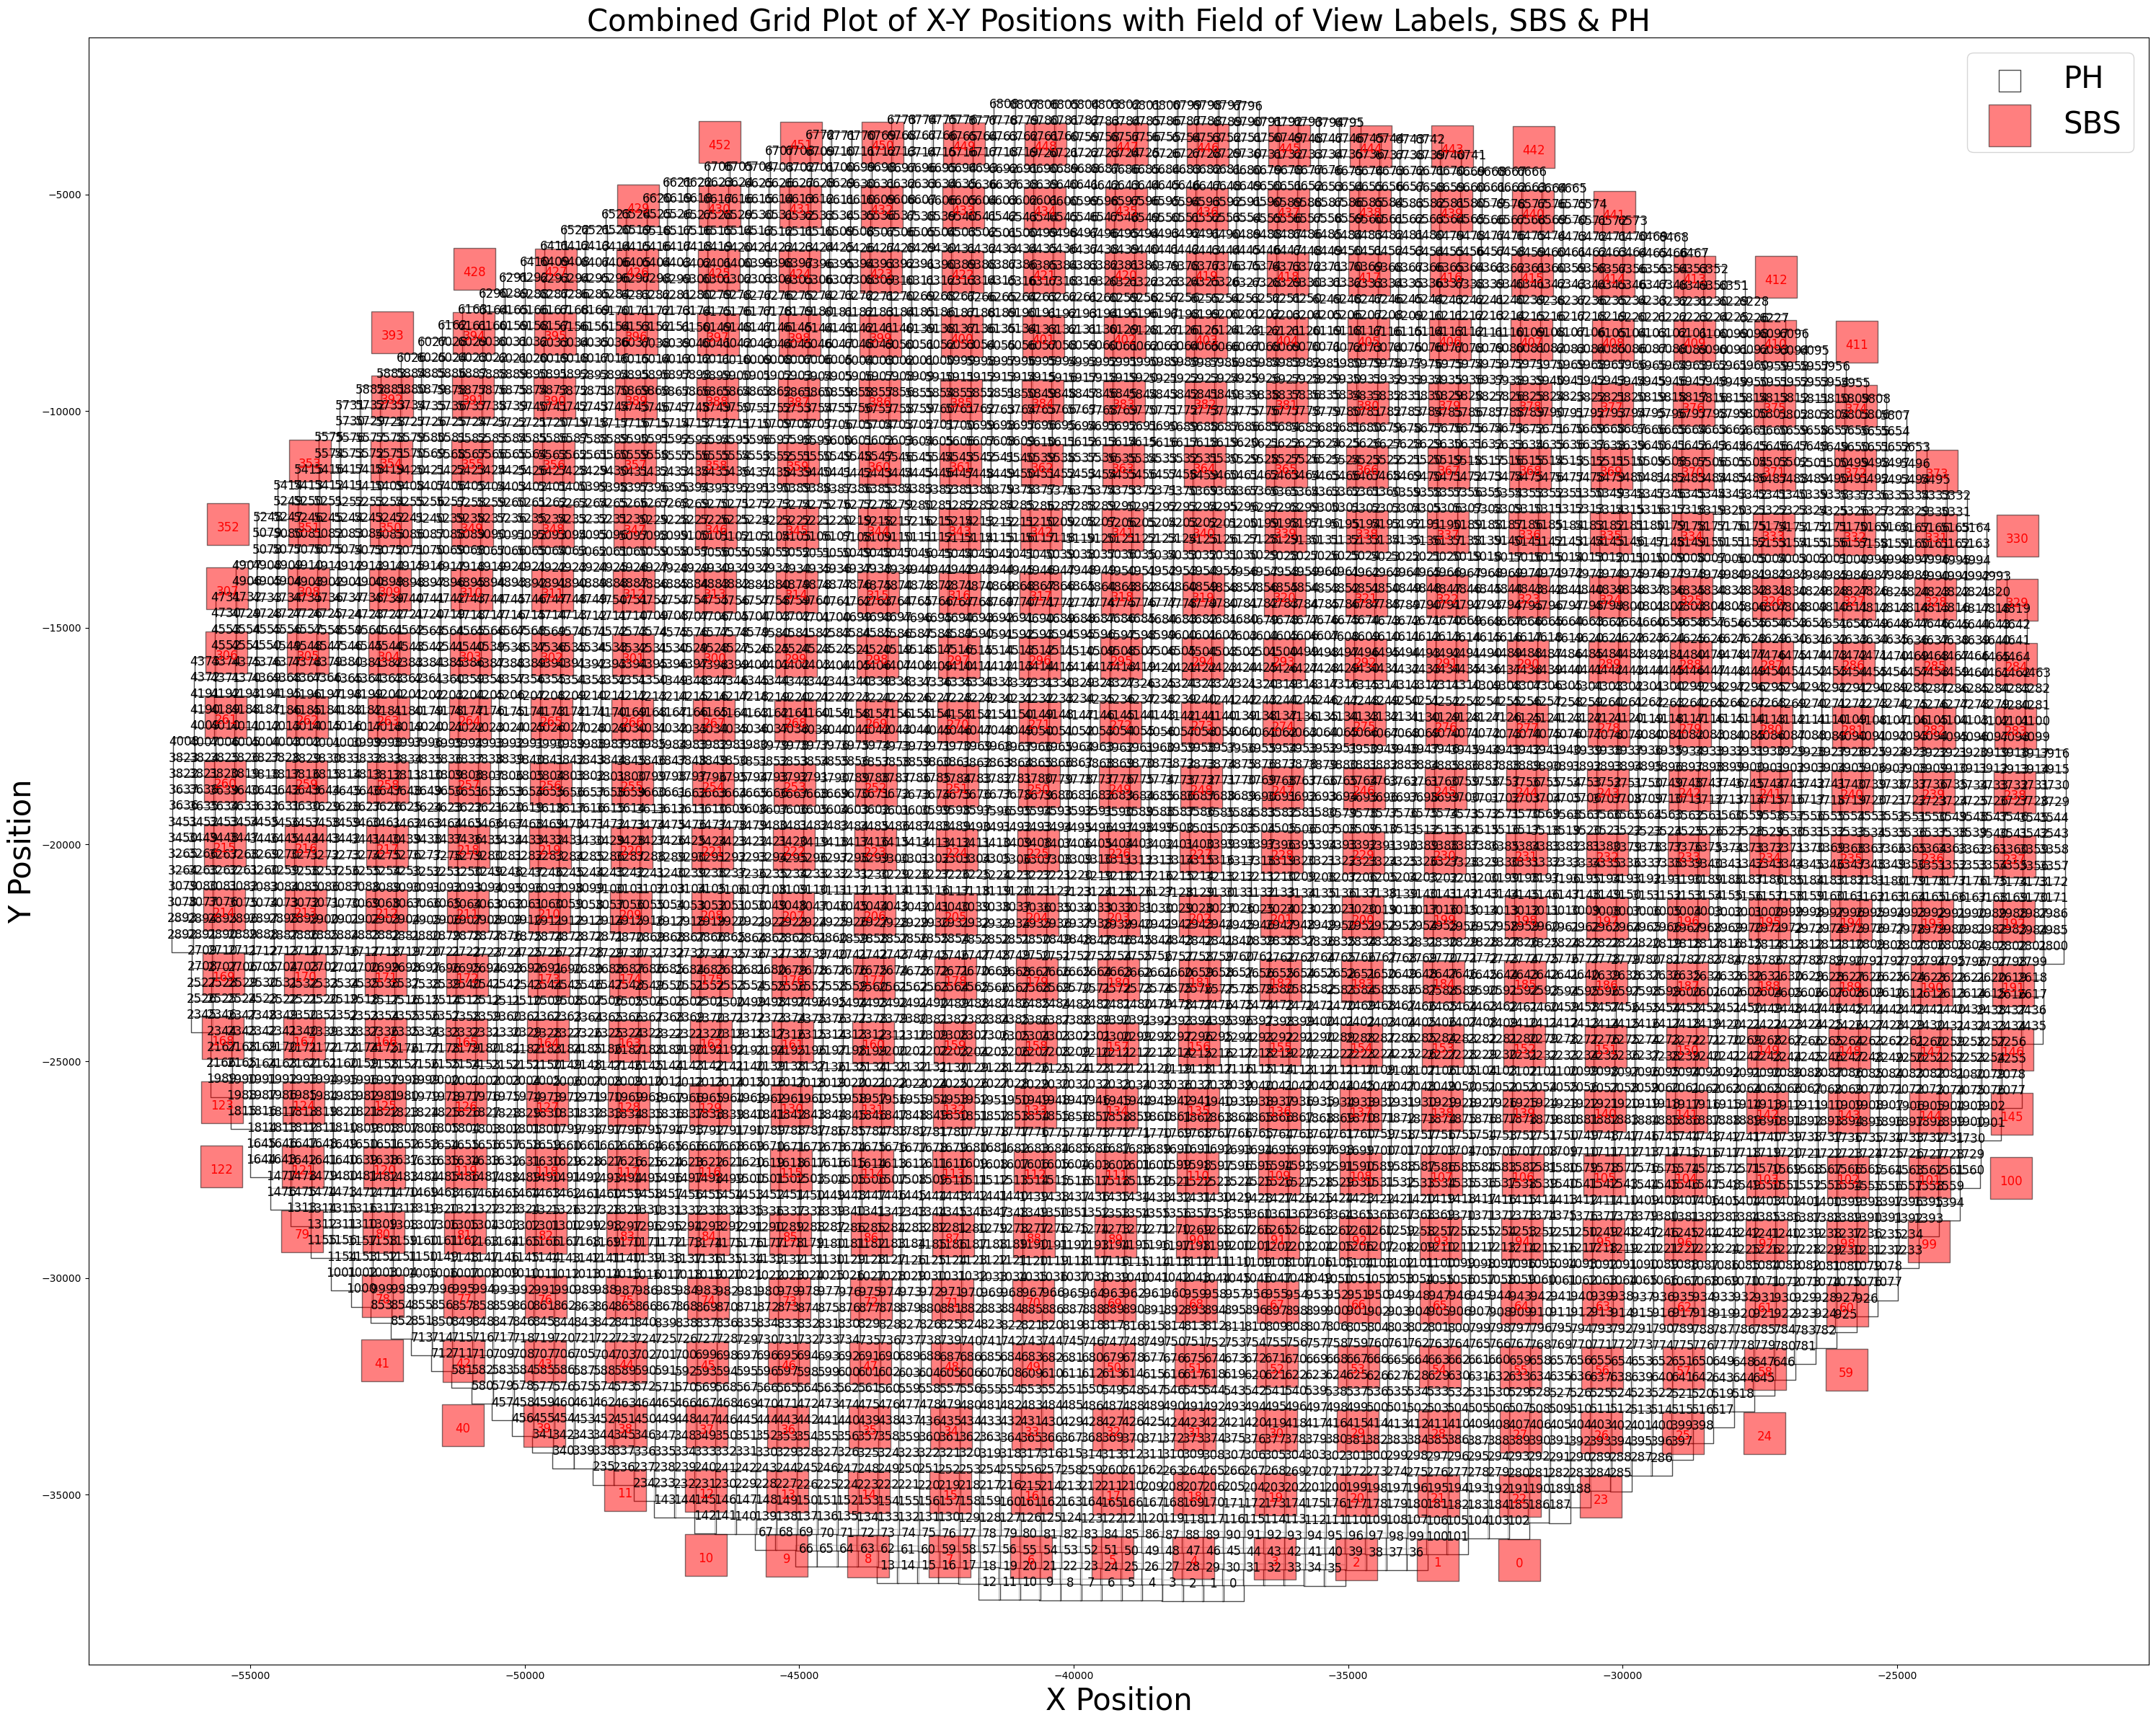

In [29]:
ROOT_FP = Path(config["all"]["root_fp"])

# load phenotype and SBS metadata dfs
ph_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if PH_METADATA_CHANNEL is not None:
    ph_filename_params["channel"] = PH_METADATA_CHANNEL

ph_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "phenotype"
    / get_filename(ph_filename_params, "combined_metadata", "parquet")
)
ph_test_metadata = pd.read_parquet(ph_test_metadata_fp)

sbs_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if SBS_METADATA_CHANNEL is not None:
    sbs_filename_params["channel"] = SBS_METADATA_CHANNEL

sbs_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "sbs"
    / get_filename(sbs_filename_params, "combined_metadata", "parquet")
)
sbs_test_metadata = pd.read_parquet(sbs_test_metadata_fp)
sbs_test_metadata = sbs_test_metadata[sbs_test_metadata["cycle"] == SBS_METADATA_CYCLE]

# create plot with combined tile view
combined_tile_grid = plot_combined_tile_grid(ph_test_metadata, sbs_test_metadata)
combined_tile_grid.show()

## <font color='red'>SET PARAMETERS</font>

### Parameters for testing merge processing

- `INITIAL_SITES`: Combinations of phenotype and SBS tiles used for configuring merge module parameters. Based on the combined grid above, set 6 aligned intial sites. We will load images for one of those sites, to ensure that we can visualize cell patterns (using the DAPI channel) that correspond between two tiles that will make up our initial sites. We recommend using aligned sites from across the plate.

In [21]:
# import pandas as pd
# import numpy as np
# from sklearn.cluster import KMeans

# # Load the data
# phenotype_info = pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/parquets/P-1_W-A3__phenotype_info.parquet")

# # Count number of cells per tile
# tile_counts = phenotype_info['tile'].value_counts().reset_index()
# tile_counts.columns = ['tile', 'cell_count']

# # Filter out tiles with more than 80 cells
# tile_counts = tile_counts[tile_counts['cell_count'] <= 65]

# # Estimate grid dimensions (assuming contiguous tile numbers starting from 0)
# n_tiles = tile_counts['tile'].max() + 1
# grid_size = int(np.ceil(np.sqrt(n_tiles)))

# # Estimate (x, y) position of each tile
# tile_counts['x'] = tile_counts['tile'] % grid_size
# tile_counts['y'] = tile_counts['tile'] // grid_size

# # Cluster tile positions into 6 geographic regions
# kmeans = KMeans(n_clusters=6, random_state=0)
# tile_counts['region'] = kmeans.fit_predict(tile_counts[['x', 'y']])

# # Pick the top tile (by cell count) from each region
# selected_tiles = tile_counts.sort_values('cell_count', ascending=False).groupby('region').first().reset_index()

# print("Selected 6 tiles:")
# print(selected_tiles[['tile', 'cell_count', 'region']])


In [22]:

# closest = find_closest_sites(ph_test_metadata, sbs_test_metadata, 3180)
# print(closest.head())


In [23]:
# INITIAL_SITES = [
#     [2795, 190], 
#     [5809, 374], 
#     [2996, 194],
#     ]

In [24]:
# import pandas as pd
# import numpy as np

# def find_closest_tiles(sbs_metadata, ph_metadata, sbs_tile_id):
#     """
#     Find closest tiles in ph_metadata to a specific tile in sbs_metadata
    
#     Args:
#         sbs_metadata: DataFrame with x_pos, y_pos columns
#         ph_metadata: DataFrame with x_pos, y_pos columns  
#         sbs_tile_id: ID of sbs tile to find neighbors for
    
#     Returns:
#         DataFrame of ph tiles sorted by distance to sbs_tile_id
#     """
#     # Get sbs tile coordinates
#     sbs_tile = sbs_metadata[sbs_metadata.tile == sbs_tile_id]
#     print(f"Finding closest tiles to SBS tile ID: {sbs_tile_id}")
#     print(f"SBS tile coordinates: {sbs_tile[['x_pos', 'y_pos']].iloc[0].to_dict()}")
#     sbs_x, sbs_y = sbs_tile['x_pos'].iloc[0], sbs_tile['y_pos'].iloc[0]
    
#     # Calculate distances to all ph tiles
#     distances = np.sqrt((ph_metadata['x_pos'] - sbs_x)**2 + (ph_metadata['y_pos'] - sbs_y)**2)
    
#     # Return sorted results
#     result = ph_metadata.copy()
#     result['distance'] = distances
#     return result.sort_values('distance')

# # # Usage:
# # closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 15)
# # print(closest.head())

# # closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 62)
# # print(closest.head())

# # closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 170)
# # print(closest.head())

# # closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 291)
# # print(closest.head())

# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 194)
# print(closest.head())

# # closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 400)
# # print(closest.head())

In [30]:
INITIAL_SITES = [[2795, 190], [2970, 195], [2603, 188], [5809, 374], [2996, 194], [2431, 147]]

In [31]:
# Derive sites for phenotype and sbs
phenotype_tiles = [site[0] for site in INITIAL_SITES]
sbs_tiles = [site[1] for site in INITIAL_SITES]

# Derive phenotype alignment hash
phenotype_info_fp = (
    ROOT_FP
    / "phenotype"
    / "parquets"
    / get_filename(
        {"plate": TEST_PLATE, "well": TEST_WELL}, "phenotype_info", "parquet"
    )
)
phenotype_info = pd.read_parquet(phenotype_info_fp)
phenotype_info_hash = hash_cell_locations(phenotype_info)

# Derive SBS alignment hash
sbs_info_fp = (
    ROOT_FP
    / "sbs"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL}, "sbs_info", "parquet")
)
sbs_info = pd.read_parquet(sbs_info_fp)
sbs_info_hash = hash_cell_locations(sbs_info).rename(columns={"tile": "site"})

# Perform alignment for initial sites
initial_alignment_df = initial_alignment(
    phenotype_info_hash, sbs_info_hash, initial_sites=INITIAL_SITES
)
initial_alignment_df

,rotation,translation,score,determinant,site,tile
0,"[[0.124336013876151, -0.0002968177053239362], ...","[734.9772849658875, 168.7622001360804]",0.332061,0.015535,190,2795
1,"[[0.12374614065876637, -0.00019601859778681664...","[165.99570957212097, 738.4886837269726]",0.375000,0.015417,195,2970
2,"[[0.1193613416000645, 0.0021917671312359807], ...","[165.85025228031066, 738.0839352390608]",0.229167,0.015250,188,2603
3,"[[0.12440625487786064, -0.0006274724773492898]...","[450.7944907402715, 452.170005433126]",0.370079,0.015611,374,5809
4,"[[0.12480915427593188, -0.0005333313209885022]...","[449.855109399731, 454.60479897990956]",0.432624,0.015504,194,2996
5,"[[0.12403971252956866, -0.00033956529354241347...","[735.0393665757531, 169.9340056015694]",0.252308,0.015410,147,2431


## <font color='red'>SET PARAMETERS</font>

### Visualize gating strategy based on initial alignment

- `DET_RANGE`: Enforces valid magnification ratios between phenotype and genotype images. It needs to be adjusted based on:
    - Objective magnifications used (e.g., 20X vs 10X)
    - Camera binning settings (e.g., 2x2 binning vs unbinned)
    - To calculate for your setup:
        1. Determine total magnification difference (objectives × binning)
        2. Use (min/difference², max/difference²) where min/max are typically 0.9-1.15
    - You can narrow or expand the suggested `DET_RANGE` based on how closely or widely you want to ensure matches
- `SCORE` This parameter is the score of the transformation, typically 0.1

In [32]:
DET_RANGE = (0.015, 0.017)
SCORE = 0.1

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Alignment Quality Check\nScore vs Determinant'}, xlabel='Determinant', ylabel='Score'>)

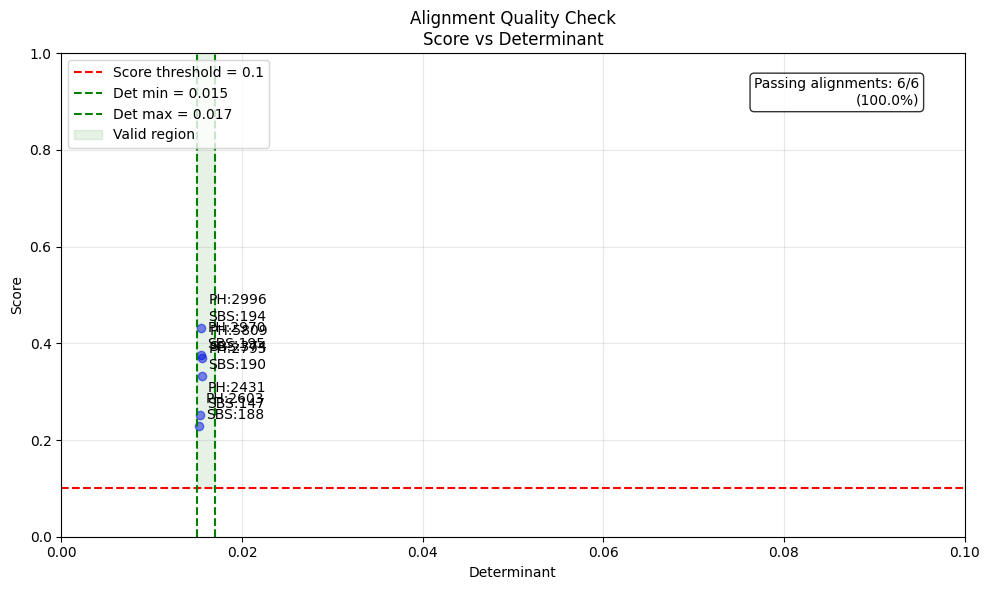

In [33]:
plot_alignment_quality(
    initial_alignment_df, det_range=DET_RANGE, score=SCORE, xlim=(0, 0.1), ylim=(0, 1)
)

## <font color='red'>SET PARAMETERS</font>

### Visualize cell matches based on initial alignment

- `THRESHOLD`: Determines the maximum euclidean distance between a phenotype point and its matched SBS point for them to be considered a valid match

In [34]:
THRESHOLD = 10

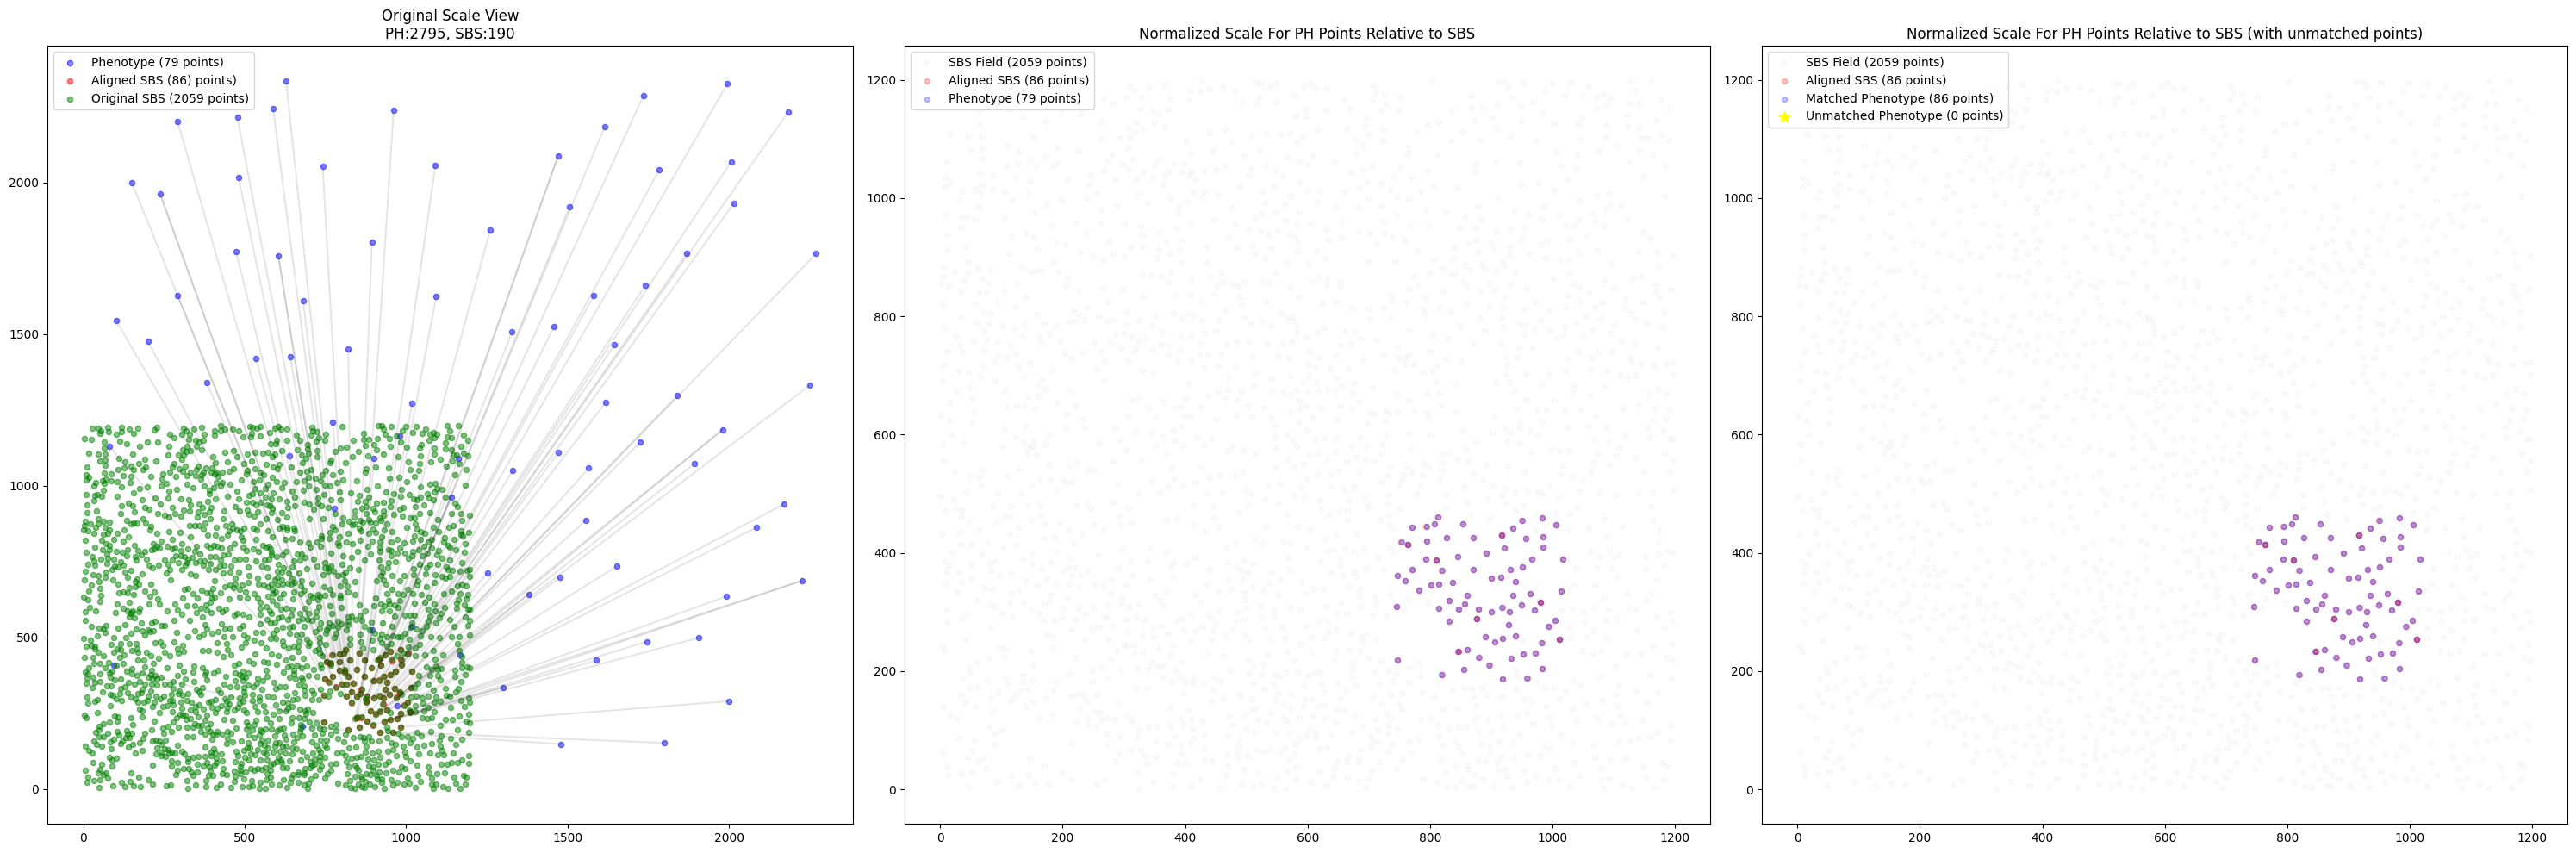

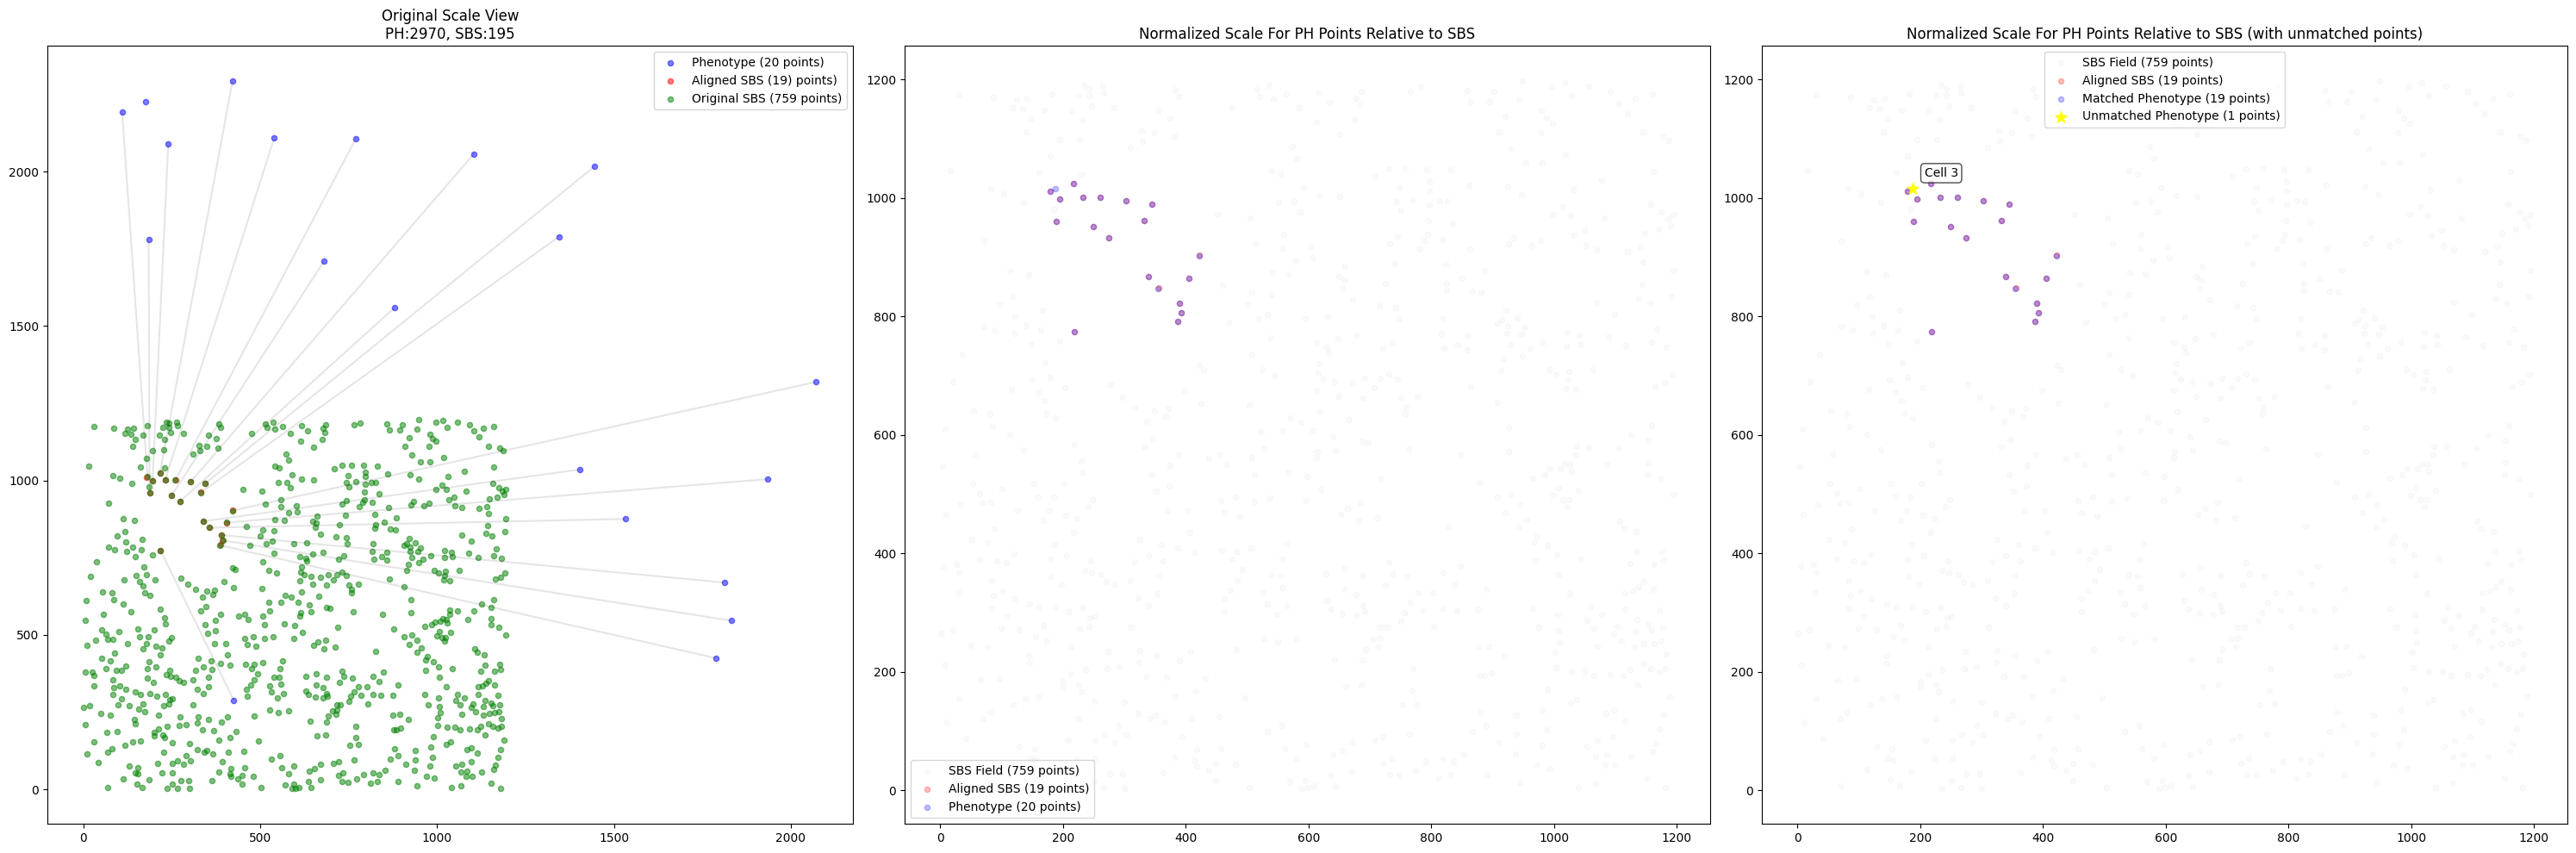

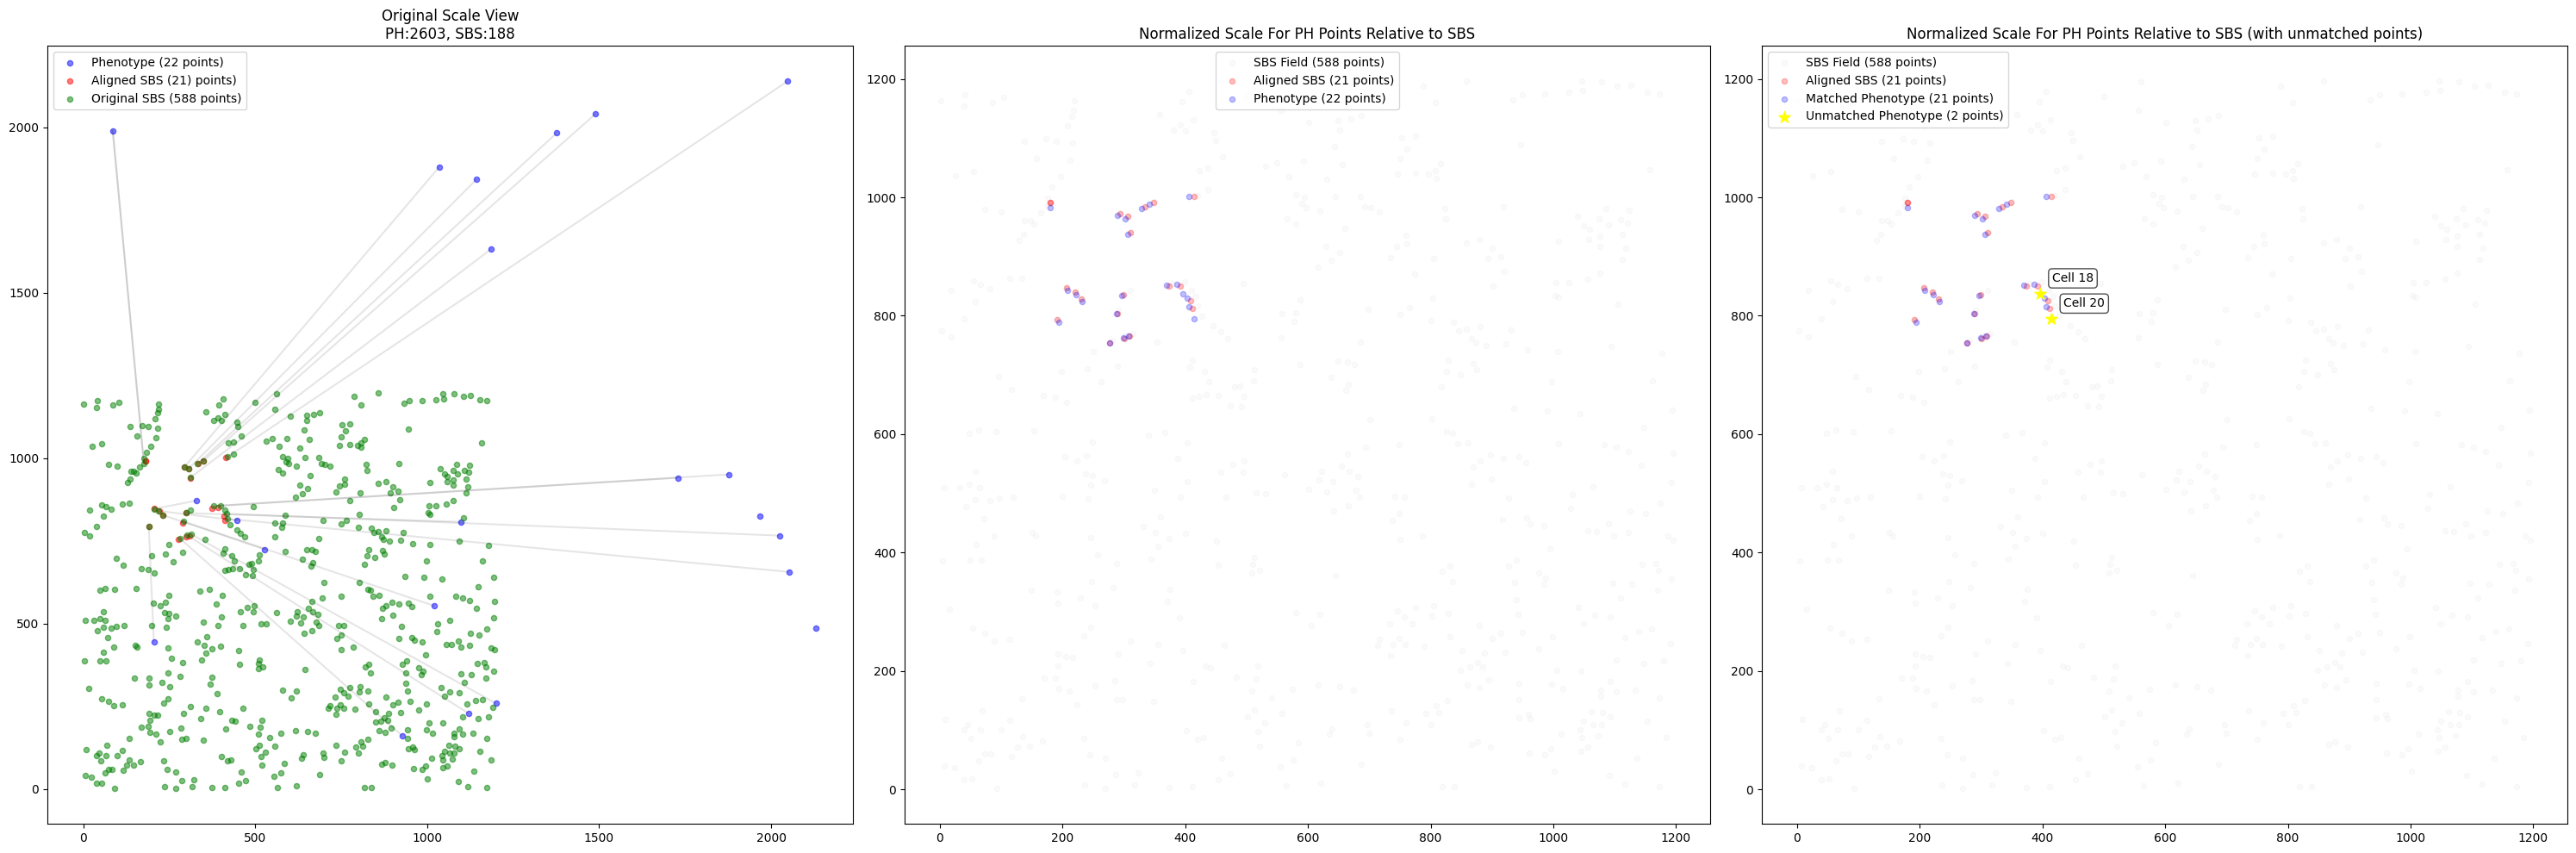

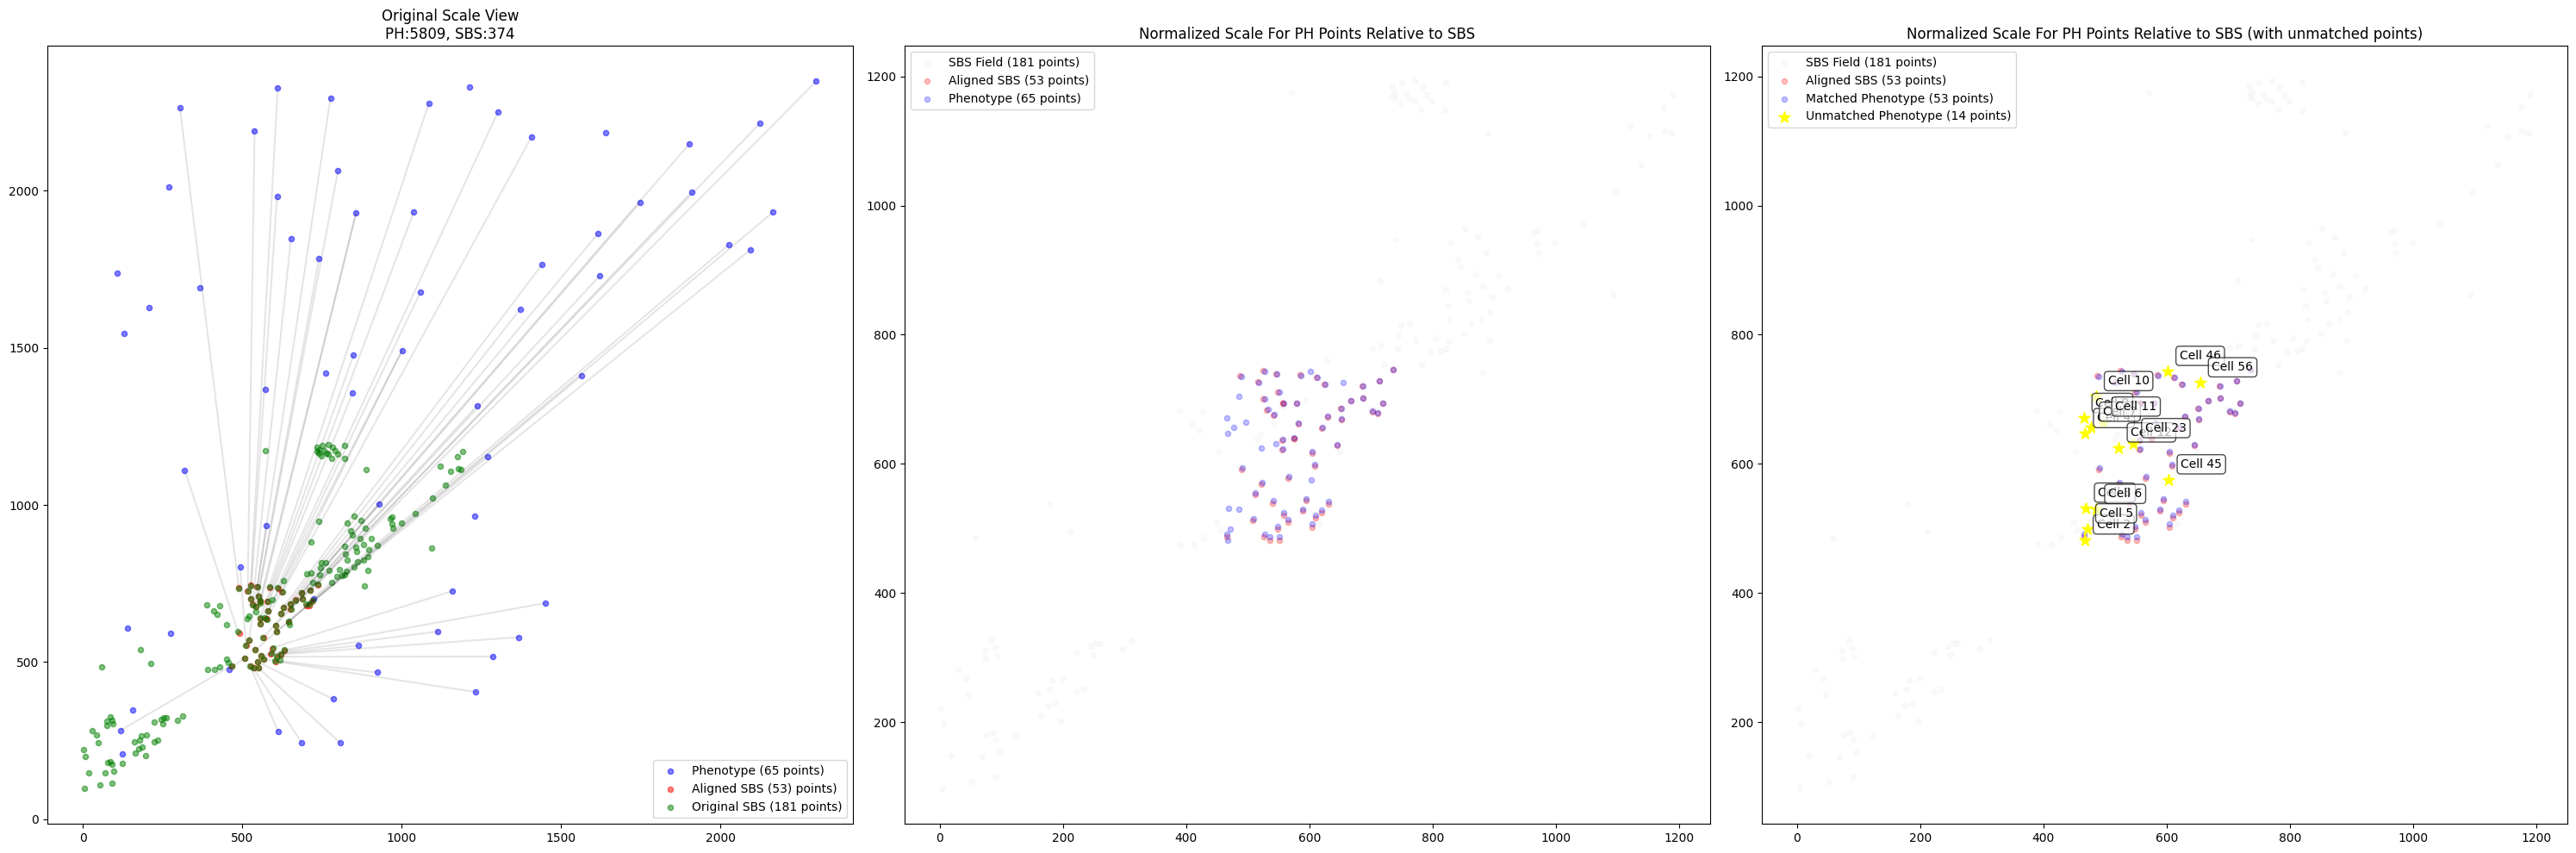

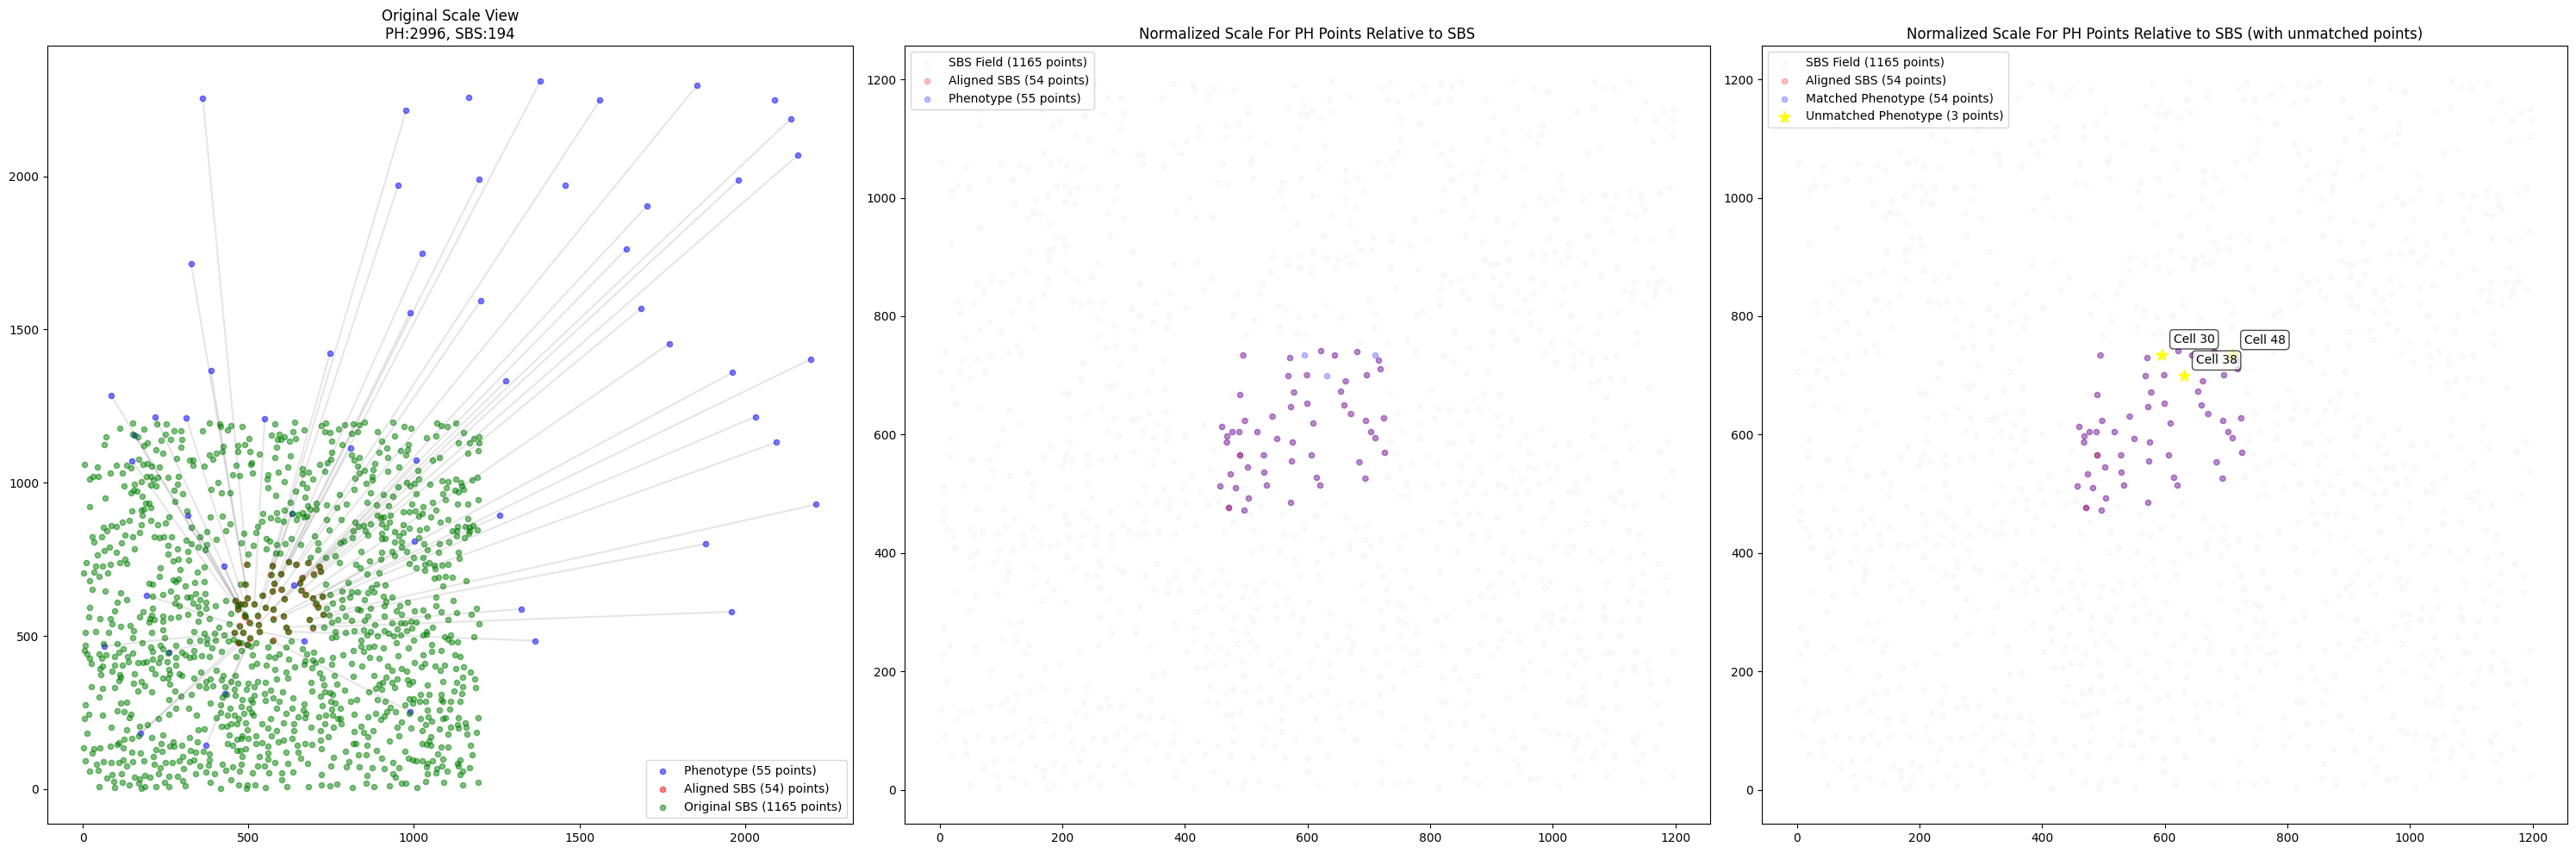

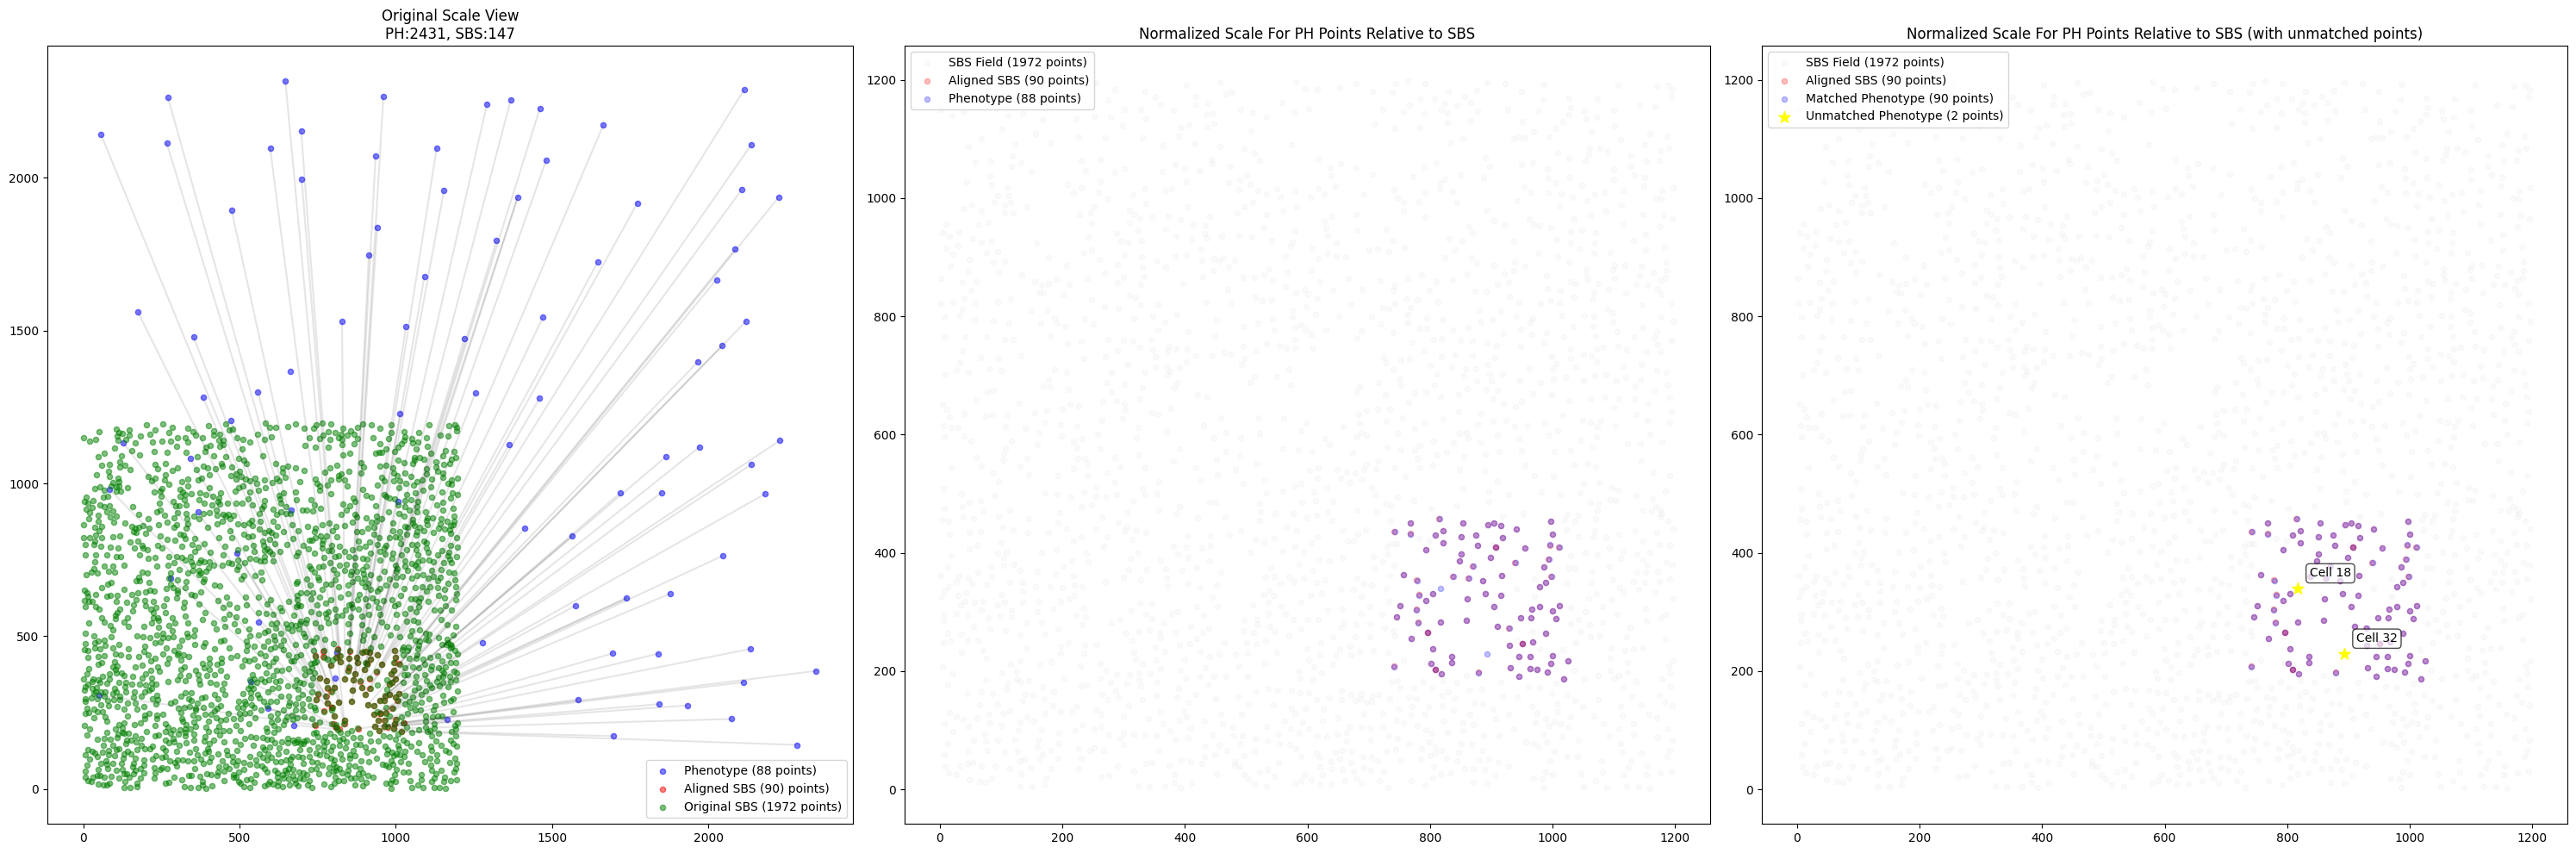

In [35]:
# Loop through all initial site pairs and create plots for each
for site_pair in INITIAL_SITES:
    ph_tile = site_pair[0]
    sbs_site = site_pair[1]
    
    # Get the alignment vector for this site pair
    alignment_vec = initial_alignment_df[
        (initial_alignment_df["tile"] == ph_tile) & 
        (initial_alignment_df["site"] == sbs_site)
    ]
    
    # Check if we found a valid alignment for this pair
    if not alignment_vec.empty:
        alignment_vec = alignment_vec.iloc[0]
        
        # Create the plot for this site pair
        plot_merge_example(
            phenotype_info,
            sbs_info,
            alignment_vec,
            threshold=THRESHOLD,
        )
    else:
        print(f"No valid alignment found for PH tile {ph_tile} and SBS site {sbs_site}")

## Add merge parameters to config file

In [36]:
import yaml
from pathlib import Path

def convert_tuples_to_lists(obj):
    """Recursively convert all tuples in a data structure to lists."""
    if isinstance(obj, tuple):
        return [convert_tuples_to_lists(i) for i in obj]
    elif isinstance(obj, list):
        return [convert_tuples_to_lists(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: convert_tuples_to_lists(v) for k, v in obj.items()}
    else:
        return obj

# Build the merge config section
config["merge"] = {
    "approach": "fast",
    "merge_combo_fp": MERGE_COMBO_DF_FP,
    "sbs_metadata_cycle": SBS_METADATA_CYCLE,
    "sbs_metadata_channel": SBS_METADATA_CHANNEL,
    "ph_metadata_channel": PH_METADATA_CHANNEL,
    "initial_sites": INITIAL_SITES,
    "det_range": DET_RANGE,
    "score": SCORE,
    "threshold": THRESHOLD,
}

# Convert tuples to lists before dumping
safe_config = convert_tuples_to_lists(config)

# Write the config safely
with open(CONFIG_FILE_PATH, "w") as config_file:
    config_file.write(CONFIG_FILE_HEADER)
    yaml.dump(safe_config, config_file, default_flow_style=False)
